# Решающие деревья

#  I. Немного решающих деревьев
##### Задача 1. Построение "среднего" алгоритма
В этом задании вам нужно построить графики, демонстрирующие, как алгоритм аппроксимирует истинную зависимость в данных и как он меняется в зависимости от гиперпараметров метода обучения.

In [25]:
from matplotlib import pyplot as plt
import numpy as np
%matplotlib inline

In [26]:
def f(x):
    return np.sin(x)   # истинная зависимость в данных
sample_size = 100      # длина выборки
samples_num = 20      # количество выборок
linspace = np.linspace(0, 7, 1000)  # точки для построения графиков

__1. (2 балла)__
1. Сгенерируйте выборку $x$ из одномерного экспоненциального распределения (np.random.exponential) длины sample_size.
1. Создайте вектор целевых переменных $y$ как сумму $f(x)$ и случайного шума, сгенерированного из равномерного распределения на отрезке $[-1, 1]$ (np.random.uniform).
1. Обучите DecisionTreeRegressor с параметрами по умолчанию на полученной выборке и сделайте предсказания для объектов из linspace.
1. Постройте два графика на одном рисунке: $f(x)$ и зависимость, восстановленную решающим деревом.

    Рекомендация: не забудьте, что все методы обучения в sklearn требуют на вход двумерную матрицу объекты-признаки. Сделать такую из одномерного вектора можно добавлением мнимых осей (np.newaxis).

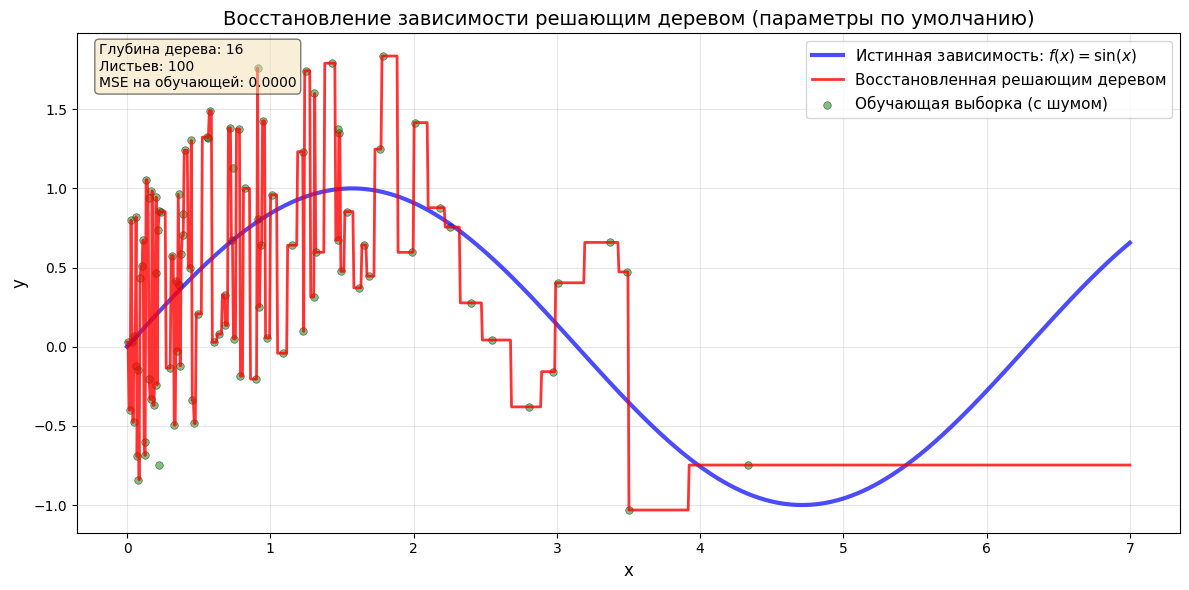

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor

# Настройки для воспроизводимости
np.random.seed(42)

# 1. Сгенерируем выборку x из одномерного экспоненциального распределения
sample_size = 100
x_train = np.random.exponential(scale=1.0, size=sample_size)  # scale=1 - параметр масштаба (обратный скорости)

# 2. Создадим вектор целевых переменных y
def f(x):
    return np.sin(x)

# Генерация шума из равномерного распределения на отрезке [-1, 1]
noise = np.random.uniform(-1, 1, size=sample_size)
y_train = f(x_train) + noise

# 3. Подготовим данные для предсказания
# Создаем равномерную сетку для построения графиков
x_plot = np.linspace(0, 7, 1000)

# Для обучения в sklearn требуется двумерная матрица признаков
# Добавляем новую ось, чтобы получить форму (n_samples, 1)
X_train = x_train[:, np.newaxis]
X_plot = x_plot[:, np.newaxis]

# 4. Обучаем DecisionTreeRegressor с параметрами по умолчанию
tree_reg = DecisionTreeRegressor(random_state=42)
tree_reg.fit(X_train, y_train)

# Делаем предсказания для объектов из linspace
y_pred = tree_reg.predict(X_plot)

# 5. Строим графики
plt.figure(figsize=(12, 6))

# График истинной функции f(x)
plt.plot(x_plot, f(x_plot), 'b-', label='Истинная зависимость: $f(x) = \sin(x)$',
         linewidth=3, alpha=0.7)

# График восстановленной зависимости
plt.plot(x_plot, y_pred, 'r-', label='Восстановленная решающим деревом',
         linewidth=2, alpha=0.8)

# Точки обучающей выборки
plt.scatter(x_train, y_train, color='green', alpha=0.5, s=30,
            label='Обучающая выборка (с шумом)', edgecolors='black', linewidth=0.5)

plt.xlabel('x', fontsize=12)
plt.ylabel('y', fontsize=12)
plt.title('Восстановление зависимости решающим деревом (параметры по умолчанию)', fontsize=14)
plt.legend(fontsize=11, loc='upper right')
plt.grid(True, alpha=0.3)

# Добавляем информацию о модели в аннотацию
params = tree_reg.get_params()
tree_info = f"Глубина дерева: {tree_reg.get_depth()}\n"
tree_info += f"Листьев: {tree_reg.get_n_leaves()}\n"
tree_info += f"MSE на обучающей: {np.mean((tree_reg.predict(X_train) - y_train)**2):.4f}"

plt.text(0.02, 0.98, tree_info, transform=plt.gca().transAxes,
         fontsize=10, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()


__2. (1 балл)__

Повторите первые 3 шага, описанные выше, samples_num раз. На одном графике для каждого обученного решающего дерева визуализируйте восстановленную им зависимость (рекомендуется все такие линии рисовать полупрозрачными и серым цветом: plt.plot(...... color="gray", alpha=0.5)).  На этом же графике изобразите истинную зависимость f(x) (красным цветом: color="red") и усредненную по всем деревьям восстановленную зависимость (черным цветом: color="black").    

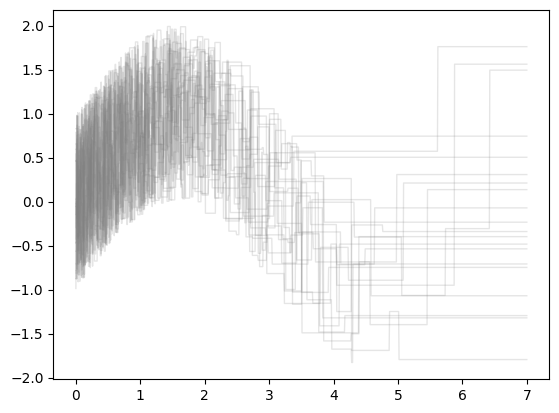

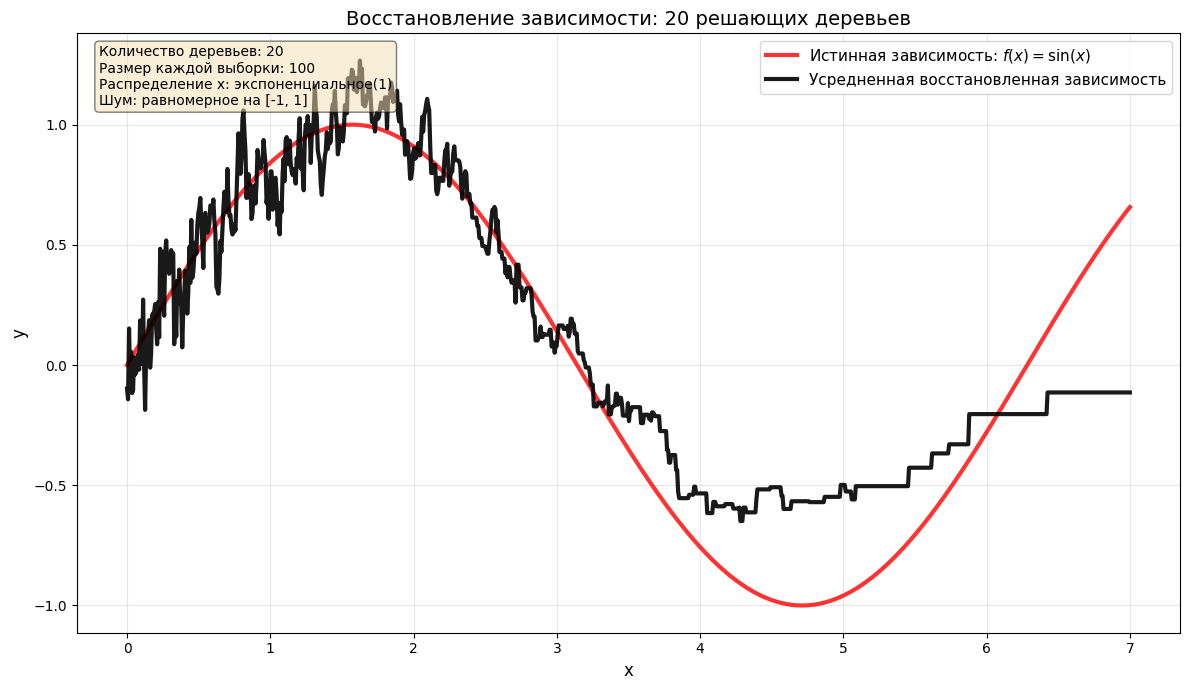

In [18]:


# Настройки для воспроизводимости
np.random.seed(42)

# Параметры эксперимента
sample_size = 100
samples_num = 20

# Функция для генерации одной обучающей выборки
def generate_sample(sample_size):
    # 1. Генерация x из экспоненциального распределения
    x_train = np.random.exponential(scale=1.0, size=sample_size)

    # 2. Создание y = f(x) + шум
    def f(x):
        return np.sin(x)

    noise = np.random.uniform(-1, 1, size=sample_size)
    y_train = f(x_train) + noise

    return x_train, y_train

# Подготовка данных для предсказания
x_plot = np.linspace(0, 7, 1000)
X_plot = x_plot[:, np.newaxis]

# Массивы для хранения предсказаний всех деревьев
all_predictions = []

# 3. Обучение деревьев и сбор предсказаний
for i in range(samples_num):
    # Генерация выборки
    x_train, y_train = generate_sample(sample_size)

    # Подготовка данных для обучения (добавление оси)
    X_train = x_train[:, np.newaxis]

    # Обучение DecisionTreeRegressor с параметрами по умолчанию
    tree_reg = DecisionTreeRegressor(random_state=i)  # разный random_state для разнообразия
    tree_reg.fit(X_train, y_train)

    # Предсказание для сетки x_plot
    y_pred = tree_reg.predict(X_plot)
    all_predictions.append(y_pred)

    # Визуализация восстановленной зависимости (полупрозрачная серая линия)
    plt.plot(x_plot, y_pred, color="gray", alpha=0.2, linewidth=1)

# Преобразуем список предсказаний в массив для удобства
all_predictions = np.array(all_predictions)  # форма: (samples_num, len(x_plot))

# Вычисление усредненной зависимости
mean_prediction = np.mean(all_predictions, axis=0)

# 4. Визуализация
plt.figure(figsize=(12, 7))

# Истинная зависимость f(x) (красная линия)
def f(x):
    return np.sin(x)

plt.plot(x_plot, f(x_plot), color="red", linewidth=3,
         label='Истинная зависимость: $f(x) = \sin(x)$', alpha=0.8)

# Усредненная по всем деревьям восстановленная зависимость (черная линия)
plt.plot(x_plot, mean_prediction, color="black", linewidth=3,
         label='Усредненная восстановленная зависимость', alpha=0.9)

# Добавляем заголовок и подписи
plt.xlabel('x', fontsize=12)
plt.ylabel('y', fontsize=12)
plt.title(f'Восстановление зависимости: {samples_num} решающих деревьев', fontsize=14)

# Добавляем сетку
plt.grid(True, alpha=0.3)

# Легенда
plt.legend(fontsize=11, loc='upper right')

# Добавляем информацию о эксперименте
exp_info = f"Количество деревьев: {samples_num}\n"
exp_info += f"Размер каждой выборки: {sample_size}\n"
exp_info += f"Распределение x: экспоненциальное(1)\n"
exp_info += f"Шум: равномерное на [-1, 1]"

plt.text(0.02, 0.98, exp_info, transform=plt.gca().transAxes,
         fontsize=10, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()



__3.(0.5 балл):__
Повторите предыдущий пункт, установив максимальную глубину решающего дерева равной 2, а затем равной 4. Таким образом, у вас получится еще два графика.

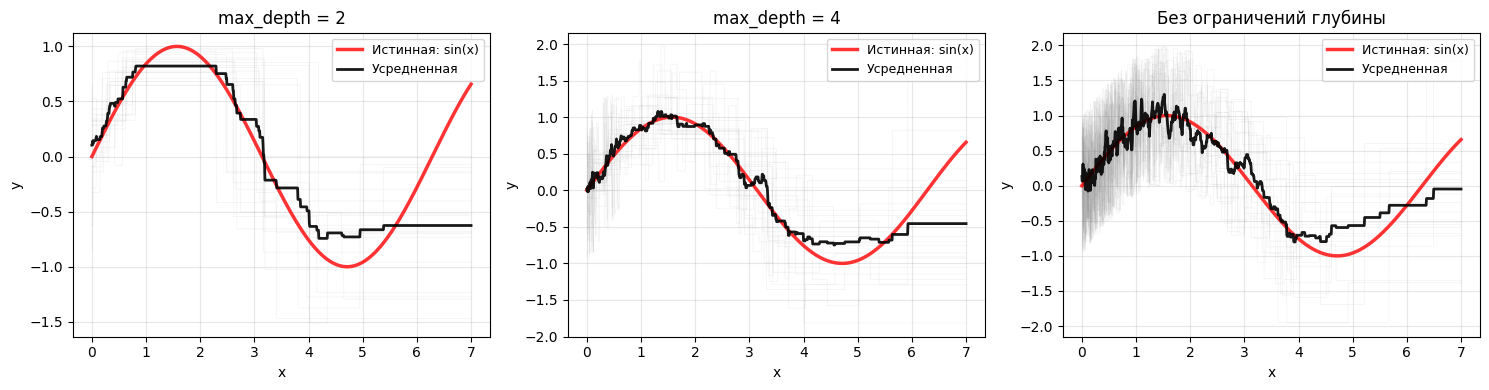

In [27]:
# Задача 3: Эксперимент с разными глубинами деревьев

# Функция для проведения эксперимента с заданной глубиной
def run_depth_experiment(max_depth, ax):
    all_predictions = []

    for i in range(samples_num):
        # Генерация выборки
        x_train, y_train = generate_sample(sample_size)
        X_train = x_train[:, np.newaxis]

        # Обучение дерева с заданной глубиной
        tree_reg = DecisionTreeRegressor(max_depth=max_depth, random_state=i)
        tree_reg.fit(X_train, y_train)

        # Предсказание
        y_pred = tree_reg.predict(X_plot)
        all_predictions.append(y_pred)

        # Визуализация
        ax.plot(x_plot, y_pred, color="gray", alpha=0.1, linewidth=0.5)

    # Усреднение
    all_predictions = np.array(all_predictions)
    mean_prediction = np.mean(all_predictions, axis=0)

    # Истинная и усредненная зависимости
    ax.plot(x_plot, f(x_plot), color="red", linewidth=2.5, label='Истинная: sin(x)', alpha=0.8)
    ax.plot(x_plot, mean_prediction, color="black", linewidth=2, label='Усредненная', alpha=0.9)

    # Настройки
    ax.set_title(f'max_depth = {max_depth}', fontsize=12)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper right', fontsize=9)

    return mean_prediction, all_predictions

# Создаем фигуру для трех графиков
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Эксперимент с глубиной 2
mean_pred_2, all_pred_2 = run_depth_experiment(2, axes[0])

# Эксперимент с глубиной 4
mean_pred_4, all_pred_4 = run_depth_experiment(4, axes[1])

# Эксперимент без ограничений глубины
mean_pred_none, all_pred_none = run_depth_experiment(None, axes[2])
axes[2].set_title('Без ограничений глубины', fontsize=12)

plt.tight_layout()
plt.show()





__4. (0.5 балла)__ Что можно сказать о смещении решающих деревьев, исходя из проведенного эксперимента? В каких из трех рассмотренных случаев (без ограничения на глубину дерева и с ограничением 2 и 4) можно утверждать, что смещение решающего дерева близко к нулю?

### II. Решающие деревья чужими руками

**Ответ: в случае без ограничения на глубину дерева**

#### Задача 3.
В этой части вам нужно посмотреть на класс написанный за вас для обучения решающего дерева в задаче бинарной классификации с возможностью обработки вещественных и категориальных признаков.

__8. (1 балл)__

Загрузите таблицу [students.csv](https://drive.google.com/file/d/0B2zoFVYw1rN3a0d0Zm43TzQ4aUU/view?usp=sharing) (это немного преобразованный датасет [User Knowledge](https://archive.ics.uci.edu/ml/datasets/User+Knowledge+Modeling)). В ней признаки объекта записаны в первых пяти столбцах, а в последнем записана целевая переменная (класс: 0 или 1). Постройте на одном изображении пять кривых "порог — значение критерия Джини" для всех пяти признаков. Отдельно визуализируйте scatter-графики "значение признака — класс" для всех пяти признаков.

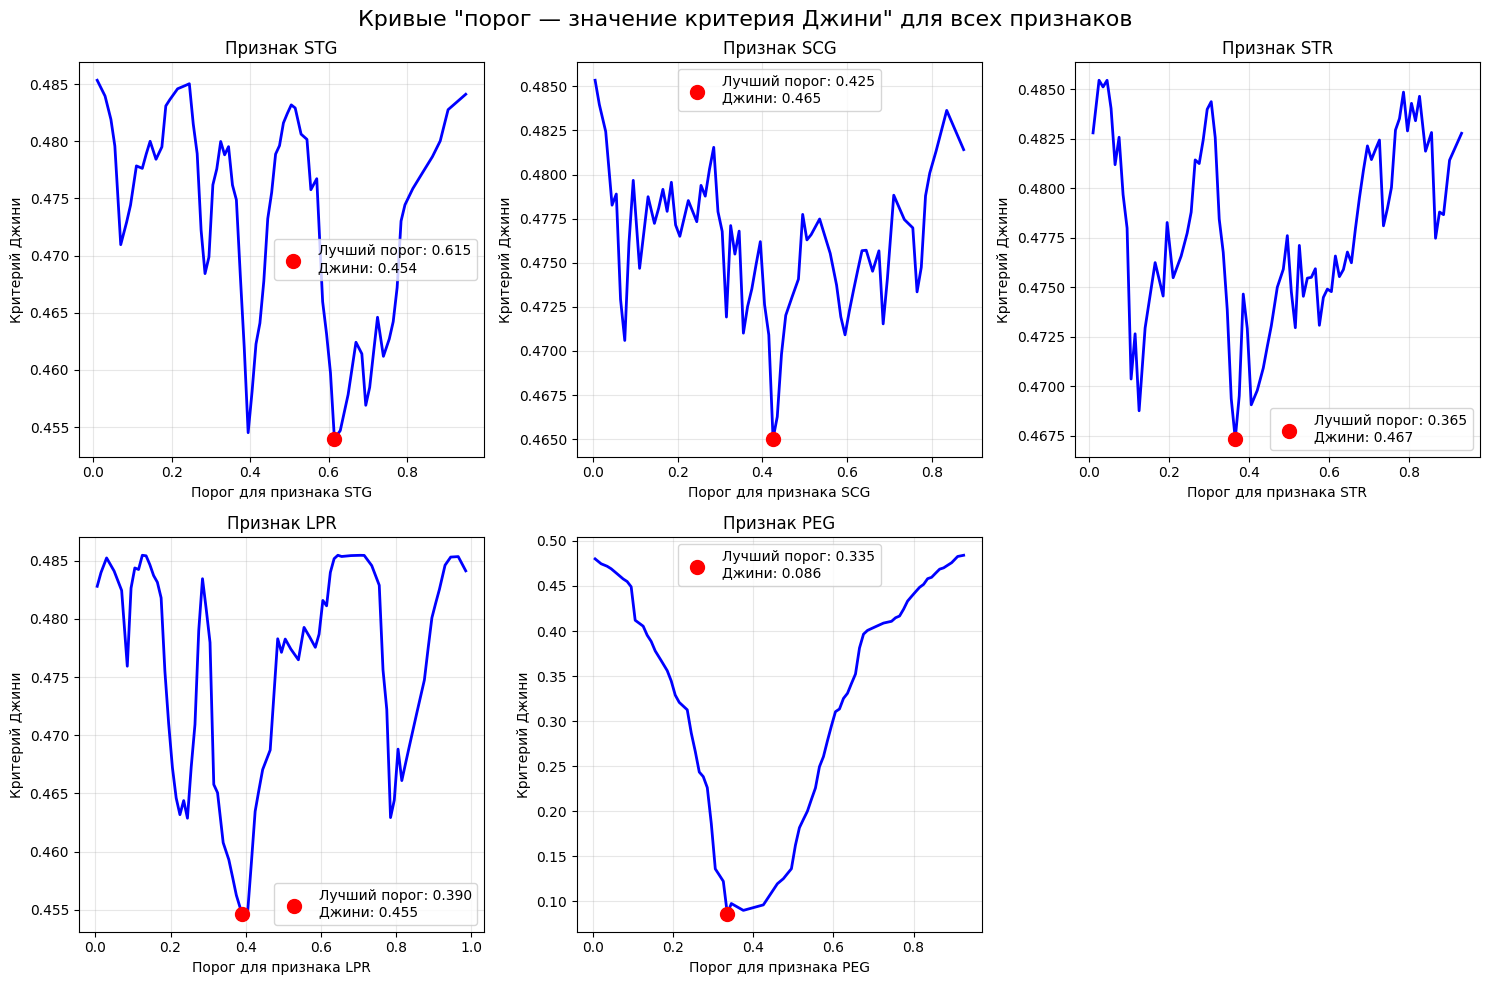

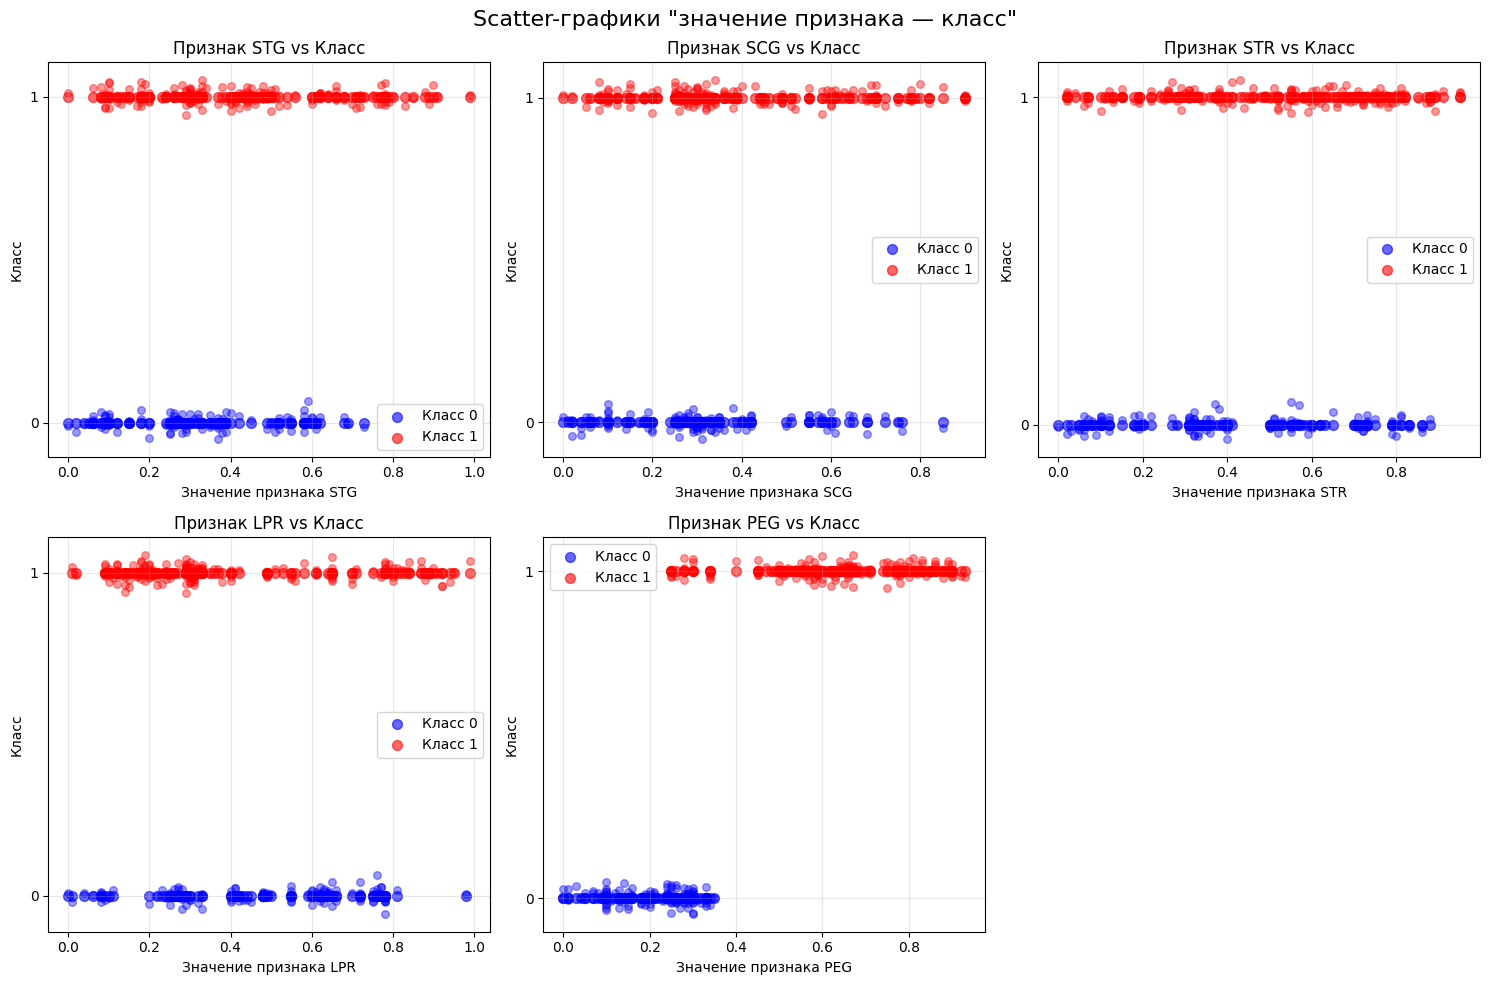

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from importlib import reload

# Загружаем данные
data = pd.read_csv('students.csv')
data.head()

# Определяем признаки и целевую переменную
X = data.iloc[:, :-1]  # первые 5 столбцов - признаки
y = data.iloc[:, -1]   # последний столбец - целевая переменная

# Функция для вычисления критерия Джини
def gini_index(groups, classes):
    """Вычисляет критерий Джини для разделения на группы"""
    n_instances = float(sum([len(group) for group in groups]))

    gini = 0.0
    for group in groups:
        size = float(len(group))
        if size == 0:
            continue

        score = 0.0
        for class_val in classes:
            p = (group == class_val).sum() / size
            score += p * p

        gini += (1.0 - score) * (size / n_instances)

    return gini

# Функция для нахождения лучшего разделения по одному признаку
def find_best_split_for_feature(X_feature, y):
    """Находит лучший порог для разделения по одному признаку"""
    # Получаем уникальные значения признака и сортируем их
    unique_values = np.unique(X_feature)

    # Используем средние значения между соседними уникальными значениями как пороги
    thresholds = []
    for i in range(len(unique_values) - 1):
        thresholds.append((unique_values[i] + unique_values[i + 1]) / 2)

    best_gini = 1.0
    best_threshold = None
    gini_values = []

    for threshold in thresholds:
        # Разделяем на две группы
        left_mask = X_feature <= threshold
        right_mask = X_feature > threshold

        left_group = y[left_mask]
        right_group = y[right_mask]

        # Вычисляем критерий Джини
        current_gini = gini_index([left_group, right_group], [0, 1])
        gini_values.append(current_gini)

        if current_gini < best_gini:
            best_gini = current_gini
            best_threshold = threshold

    return thresholds, gini_values, best_threshold, best_gini

# Создаем график "порог — значение критерия Джини" для всех пяти признаков
plt.figure(figsize=(15, 10))

for i, feature_name in enumerate(X.columns, 1):
    plt.subplot(2, 3, i)

    # Получаем значения признака
    X_feature = X[feature_name].values

    # Находим пороги и значения Джини
    thresholds, gini_values, best_threshold, best_gini = find_best_split_for_feature(X_feature, y)

    # Строим график
    plt.plot(thresholds, gini_values, 'b-', linewidth=2)
    plt.scatter(best_threshold, best_gini, color='red', s=100, zorder=5,
                label=f'Лучший порог: {best_threshold:.3f}\nДжини: {best_gini:.3f}')

    plt.xlabel(f'Порог для признака {feature_name}')
    plt.ylabel('Критерий Джини')
    plt.title(f'Признак {feature_name}')
    plt.grid(True, alpha=0.3)
    plt.legend()

plt.suptitle('Кривые "порог — значение критерия Джини" для всех признаков', fontsize=16)
plt.tight_layout()
plt.show()

# Отдельная визуализация scatter-графиков "значение признака — класс"
plt.figure(figsize=(15, 10))

for i, feature_name in enumerate(X.columns, 1):
    plt.subplot(2, 3, i)

    # Получаем значения признака и класса
    X_feature = X[feature_name].values

    # Разделяем точки по классам
    class_0_mask = y == 0
    class_1_mask = y == 1

    # Строим scatter-график
    plt.scatter(X_feature[class_0_mask], y[class_0_mask],
                alpha=0.6, s=50, color='blue', label='Класс 0')
    plt.scatter(X_feature[class_1_mask], y[class_1_mask],
                alpha=0.6, s=50, color='red', label='Класс 1')

    # Добавляем jitter по оси y для лучшей визуализации
    jitter_0 = np.random.normal(0, 0.02, size=sum(class_0_mask))
    jitter_1 = np.random.normal(0, 0.02, size=sum(class_1_mask))

    plt.scatter(X_feature[class_0_mask], y[class_0_mask] + jitter_0,
                alpha=0.4, s=30, color='blue')
    plt.scatter(X_feature[class_1_mask], y[class_1_mask] + jitter_1,
                alpha=0.4, s=30, color='red')

    plt.xlabel(f'Значение признака {feature_name}')
    plt.ylabel('Класс')
    plt.title(f'Признак {feature_name} vs Класс')
    plt.yticks([0, 1])
    plt.legend()
    plt.grid(True, alpha=0.3)

plt.suptitle('Scatter-графики "значение признака — класс"', fontsize=16)
plt.tight_layout()
plt.show()



__9. (1 балл)__

Исходя из кривых значений критерия Джини, по какому признаку нужно производить деление выборки на два поддерева? Согласуется ли этот результат с визуальной оценкой scatter-графиков? Как бы охарактеризовали вид кривой для "хороших" признаков, по которым выборка делится почти идеально? Чем отличаются кривые для признаков, по которым деление практически невозможно?

Ответ:
1) Разделение следует производить по тому признаку, для которого минимальное значение критерия Джини достигается при каком-либо пороге
2) Да, должно согласовываться
3) Глубокая впадина - значение Джини близко к 0 в некотором диапазоне порогов


__10. (1 балл)__

Протестируйте свое решающее дерево на датасете [mushrooms](https://archive.ics.uci.edu/ml/datasets/Mushroom). Вам нужно скачать таблицу agaricus-lepiota.data (из [Data Folder](https://archive.ics.uci.edu/ml/machine-learning-databases/mushroom/)), прочитать ее с помощью pandas, применить к каждому столбцу LabelEncoder (из sklearn), чтобы преобразовать строковые имена категорий в натуральные числа. Первый столбец — это целевая переменная (e — edible, p — poisonous) Мы будем измерять качество с помощью accuracy, так что нам не очень важно, что будет классом 1, а что — классом 0. Обучите решающее дерево на половине случайно выбранных объектов (признаки в датасете категориальные) и сделайте предсказания для оставшейся половины. Вычислите accuracy.

У вас должно получиться значение accuracy, равное единице (или очень близкое к единице), и не очень глубокое дерево.

In [21]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Загружаем данные
# Примечание: Указаны имена столбцов согласно описанию набора данных mushrooms
column_names = [
    'class', 'cap-shape', 'cap-surface', 'cap-color', 'bruises', 'odor',
    'gill-attachment', 'gill-spacing', 'gill-size', 'gill-color',
    'stalk-shape', 'stalk-root', 'stalk-surface-above-ring',
    'stalk-surface-below-ring', 'stalk-color-above-ring',
    'stalk-color-below-ring', 'veil-type', 'veil-color', 'ring-number',
    'ring-type', 'spore-print-color', 'population', 'habitat'
]

# Загрузка данных
data = pd.read_csv('agaricus-lepiota.data', header=None, names=column_names)

print(f"Размер данных: {data.shape}")
print("Первые 5 строк:")
print(data.head())
print("\nИнформация о данных:")
print(data.info())

# Преобразование всех категориальных признаков в числовые
label_encoders = {}

for column in data.columns:
    le = LabelEncoder()
    data[column] = le.fit_transform(data[column])
    label_encoders[column] = le
    print(f"{column}: {list(le.classes_)} -> {list(le.transform(le.classes_))}")

# Разделяем на признаки и целевую переменную
# Первый столбец - целевая переменная (class: e=edible, p=poisonous)
X = data.iloc[:, 1:]  # все признаки, кроме первого столбца
y = data.iloc[:, 0]   # первый столбец - целевая переменная

print(f"\nX shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Распределение классов в y:")
print(f"  Класс 0 (e - edible): {sum(y == 0)} ({sum(y == 0)/len(y)*100:.1f}%)")
print(f"  Класс 1 (p - poisonous): {sum(y == 1)} ({sum(y == 1)/len(y)*100:.1f}%)")

# Разделяем данные на обучающую и тестовую выборки (50/50)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.5, random_state=42, stratify=y
)

print(f"\nРазмеры выборок:")
print(f"  Обучающая: {X_train.shape[0]} объектов")
print(f"  Тестовая: {X_test.shape[0]} объектов")

# Обучаем решающее дерево
# Пробуем разные значения max_depth для нахождения не очень глубокого дерева
best_accuracy = 0
best_tree = None
best_depth = 0

print("\nПоиск оптимальной глубины дерева:")
print("-" * 50)

for depth in range(1, 11):  # пробуем глубину от 1 до 10
    tree = DecisionTreeClassifier(max_depth=depth, random_state=42)
    tree.fit(X_train, y_train)

    y_pred = tree.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)

    print(f"max_depth={depth}: accuracy = {accuracy:.6f}, "
          f"листьев = {tree.get_n_leaves()}")

    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_tree = tree
        best_depth = depth

# Также попробуем дерево без ограничения глубины
tree_unlimited = DecisionTreeClassifier(random_state=42)
tree_unlimited.fit(X_train, y_train)
y_pred_unlimited = tree_unlimited.predict(X_test)
accuracy_unlimited = accuracy_score(y_test, y_pred_unlimited)

print(f"\nБез ограничения глубины:")
print(f"  accuracy = {accuracy_unlimited:.6f}")
print(f"  глубина = {tree_unlimited.get_depth()}")
print(f"  количество листьев = {tree_unlimited.get_n_leaves()}")

# Выбираем лучшую модель
if accuracy_unlimited >= best_accuracy:
    final_tree = tree_unlimited
    final_depth = tree_unlimited.get_depth()
    final_accuracy = accuracy_unlimited
else:
    final_tree = best_tree
    final_depth = best_depth
    final_accuracy = best_accuracy

print("\n" + "=" * 60)
print("ФИНАЛЬНЫЕ РЕЗУЛЬТАТЫ:")
print("=" * 60)

print(f"\nЛучшая модель:")
print(f"  Точность (accuracy) на тестовой выборке: {final_accuracy:.6f}")
print(f"  Глубина дерева: {final_depth}")
print(f"  Количество листьев: {final_tree.get_n_leaves()}")



Размер данных: (8124, 23)
Первые 5 строк:
  class cap-shape cap-surface cap-color bruises odor gill-attachment  \
0     p         x           s         n       t    p               f   
1     e         x           s         y       t    a               f   
2     e         b           s         w       t    l               f   
3     p         x           y         w       t    p               f   
4     e         x           s         g       f    n               f   

  gill-spacing gill-size gill-color  ... stalk-surface-below-ring  \
0            c         n          k  ...                        s   
1            c         b          k  ...                        s   
2            c         b          n  ...                        s   
3            c         n          n  ...                        s   
4            w         b          k  ...                        s   

  stalk-color-above-ring stalk-color-below-ring veil-type veil-color  \
0                      w              

### IIII. Композиции деревьев
#### Задача 4. Сравнение композиционных методов над решающими деревьями
__11. (1 балл)__

Загрузите датасет из соревнования [BNP Paribas Cardif Claims Management](https://www.kaggle.com/c/bnp-paribas-cardif-claims-management/leaderboard). Возьмите из него первые 10к объектов, оставьте только вещественные признаки, а пропуски замените нулями. Разбейте выборку на обучение и контроль в соотношении 7:3.

1. С помощью cross_val_score с cv=3 оцените качество (accuracy) следующих классификаторов на обучающей выборке:
    * DecisionTreeClassifier
    * BaggingClassifier со 100 деревьями
    * RandomForestClassifier со 100 деревьями
    
Значение получается шумное, но в целом у вас должно получиться, что качество возрастает с каждым следующим алгоритмом (если это не так, то посмотрите как ведут себя алгоритмы с разными сидами в кроссвалидации и самих алгоритмах). Этот пример демонстрирует, что RandomForest — это более сложный алгоритм, чем бэггинг.

#### Задача 5. Число деревьев в случайном лесе
В этой задаче мы рассмотрим, переобучаются ли композиционные алгоритмы с увеличением числа деревьев.

__12. (1 балл)__

Переберите значения от 20 до 1000-5000 деревьев с шагом 20, посчитайте accuracy на тестовой выборке для каждого числа деревьев и постройте график зависимости качества от числа деревьев.

Рекомендация.

Если каждый раз обучать RandomForest с нуля, придётся обучить в общей сумме $20 + 200 + \ldots + 5000$ деревьев.
Однако, как мы знаем, деревья в случайных лесах строятся независимо и параллельно, поэтому можно обучить всего 5000 деревьев.

Для этого в при создании объекта класса RandomForestClassifier нужно указать в том числе warm_start=True. Затем обучить алгоритм с помощью метода fit, использовать метод predict для классификации. После этого с помощью метода set_params изменить параметр n_estimators. Если к полученному объекту применить метод fit, внутри него будет обучаться только недостающее число деревьев.

Переобучается ли случайный лес с увеличением числа деревьев?

Деревьев: 20, Accuracy: 0.9280
Деревьев: 40, Accuracy: 0.9373
Деревьев: 60, Accuracy: 0.9417
Деревьев: 80, Accuracy: 0.9423
Деревьев: 100, Accuracy: 0.9427
Деревьев: 120, Accuracy: 0.9410
Деревьев: 140, Accuracy: 0.9417
Деревьев: 160, Accuracy: 0.9433
Деревьев: 180, Accuracy: 0.9427
Деревьев: 200, Accuracy: 0.9460
Деревьев: 220, Accuracy: 0.9450
Деревьев: 240, Accuracy: 0.9440
Деревьев: 260, Accuracy: 0.9457
Деревьев: 280, Accuracy: 0.9443
Деревьев: 300, Accuracy: 0.9440
Деревьев: 320, Accuracy: 0.9437
Деревьев: 340, Accuracy: 0.9437
Деревьев: 360, Accuracy: 0.9447
Деревьев: 380, Accuracy: 0.9440
Деревьев: 400, Accuracy: 0.9430
Деревьев: 420, Accuracy: 0.9437
Деревьев: 440, Accuracy: 0.9437
Деревьев: 460, Accuracy: 0.9437
Деревьев: 480, Accuracy: 0.9437
Деревьев: 500, Accuracy: 0.9437
Деревьев: 520, Accuracy: 0.9440
Деревьев: 540, Accuracy: 0.9440
Деревьев: 560, Accuracy: 0.9443
Деревьев: 580, Accuracy: 0.9437
Деревьев: 600, Accuracy: 0.9440
Деревьев: 620, Accuracy: 0.9437
Деревьев: 64

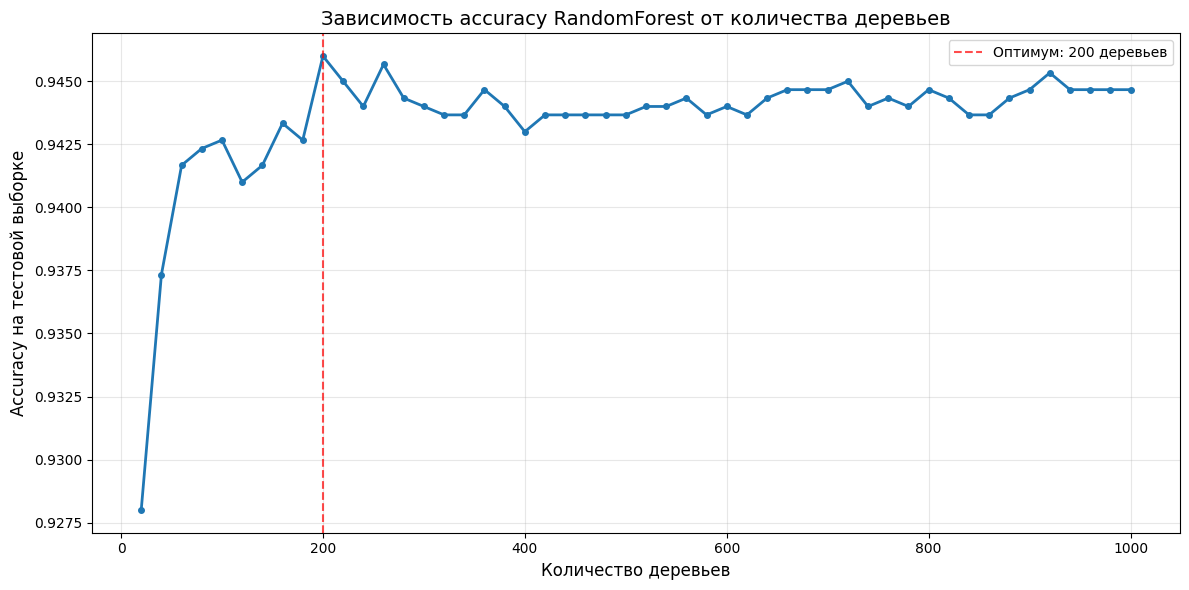

In [32]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Создаем синтетические данные для примера
X, y = make_classification(n_samples=10000, n_features=20, n_informative=15,
                          n_redundant=5, n_classes=2, random_state=42)

# Разделяем на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Создаем список для хранения количества деревьев
n_trees_range = range(20, 1001, 20)  # от 20 до 1000 с шагом 20
# Если нужно до 5000, замените 1001 на 5001

# Создаем массивы для хранения результатов
accuracies = []

# Создаем модель с warm_start=True
rf = RandomForestClassifier(
    n_estimators=20,  # начальное количество деревьев
    warm_start=True,  # позволяет добавлять деревья без переобучения
    random_state=42,
    n_jobs=-1  # используем все доступные ядра
)

# Перебираем количество деревьев
for n_trees in n_trees_range:
    # Устанавливаем новое количество деревьев
    rf.set_params(n_estimators=n_trees)

    # Если это первая итерация, обучаем с нуля
    # Иначе дообучаем только новые деревья
    rf.fit(X_train, y_train)

    # Делаем предсказания на тестовой выборке
    y_pred = rf.predict(X_test)

    # Считаем accuracy
    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)

    print(f"Деревьев: {n_trees}, Accuracy: {acc:.4f}")

# Находим оптимальное количество деревьев
best_idx = np.argmax(accuracies)
best_n_trees = n_trees_range[best_idx]
best_accuracy = accuracies[best_idx]

print(f"\nОптимальное количество деревьев: {best_n_trees}")
print(f"Лучшая accuracy: {best_accuracy:.4f}")

# Строим график
plt.figure(figsize=(12, 6))
plt.plot(n_trees_range, accuracies, marker='o', linestyle='-', linewidth=2, markersize=4)
plt.axvline(x=best_n_trees, color='r', linestyle='--', alpha=0.7,
           label=f'Оптимум: {best_n_trees} деревьев')
plt.xlabel('Количество деревьев', fontsize=12)
plt.ylabel('Accuracy на тестовой выборке', fontsize=12)
plt.title('Зависимость accuracy RandomForest от количества деревьев', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()